In [8]:
# 1. 필수 라이브러리 설치 (에러 방지를 위해 필요한 모든 패키지 포함)
!pip install summa
!pip install beautifulsoup4
!pip install tensorflow

# 2. 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.request
from bs4 import BeautifulSoup
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.callbacks import EarlyStopping
from summa.summarizer import summarize
import nltk
from nltk.corpus import stopwords

# 3. NLTK 불용어 사전 다운로드
nltk.download('stopwords')
print("✅ 패키지 설치 및 임포트 완료!")

✅ 패키지 설치 및 임포트 완료!


[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# 1. 데이터 로드 및 분석 단계
data = pd.read_csv('news_summary_more.csv', encoding='utf-8')

# 빠른 실습과 메모리 부족(OOM) 방지를 위해 샘플 10,000개만 무작위 추출하여 사용합니다.
# (전체 데이터 학습 시 코드가 멈출 수 있으므로, 실습용으로 크기를 줄입니다.)
data = data.sample(10000, random_state=42).reset_index(drop=True)

print("전체 샘플 수:", len(data))
data.drop_duplicates(subset=['text'], inplace=True)
data.dropna(axis=0, inplace=True)
print("중복/결측치 제거 후 샘플 수:", len(data))

# 2. 정규화 사전 및 불용어 
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not"}
stop_words = set(stopwords.words('english'))

# 3. 데이터 정제 함수 (정제 단계) - lxml 에러 방지를 위해 html.parser 사용
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()
    # 에러 해결: lxml 대신 내장 html.parser 사용
    sentence = BeautifulSoup(sentence, "html.parser").text 
    sentence = re.sub(r'\([^)]*\)', '', sentence)
    sentence = re.sub('"','', sentence)
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")])
    sentence = re.sub(r"'s\b","", sentence)
    sentence = re.sub("[^a-zA-Z]", " ", sentence)
    sentence = re.sub('[m]{2,}', 'mm', sentence)
    
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stop_words if len(word) > 1)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

# 4. 텍스트 및 요약 데이터 전처리 실행
clean_text = [preprocess_sentence(s) for s in data['text']]
clean_summary = [preprocess_sentence(s, False) for s in data['headlines']]

data['text'] = clean_text
data['headlines'] = ['sostoken ' + s + ' eostoken' for s in clean_summary]

# 5. 데이터셋 분리 (길이 제한 분석)
text_max_len = 40
summary_max_len = 11

data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= summary_max_len)]

text_values = data['text'].values
summary_values = data['headlines'].values

# 데이터 섞기 및 8:2 분리
indices = np.arange(text_values.shape[0])
np.random.shuffle(indices)
text_values = text_values[indices]
summary_values = summary_values[indices]

n_of_val = int(len(text_values) * 0.2)
encoder_input_train = text_values[:-n_of_val]
decoder_input_train = summary_values[:-n_of_val]
encoder_input_test = text_values[-n_of_val:]
decoder_input_test = summary_values[-n_of_val:]

# 6. 인코딩 과정 (단어사전 생성 및 정수 인코딩, 패딩)
src_vocab = 5000
src_tokenizer = Tokenizer(num_words=src_vocab)
src_tokenizer.fit_on_texts(encoder_input_train)

encoder_input_train = src_tokenizer.texts_to_sequences(encoder_input_train)
encoder_input_test = src_tokenizer.texts_to_sequences(encoder_input_test)

tar_vocab = 2000
tar_tokenizer = Tokenizer(num_words=tar_vocab)
tar_tokenizer.fit_on_texts(decoder_input_train)

decoder_input_train = tar_tokenizer.texts_to_sequences(decoder_input_train)
decoder_input_test = tar_tokenizer.texts_to_sequences(decoder_input_test)

# 패딩 (길이 맞추기)
encoder_input_train = pad_sequences(encoder_input_train, maxlen=text_max_len, padding='post')
encoder_input_test = pad_sequences(encoder_input_test, maxlen=text_max_len, padding='post')
decoder_input_train = pad_sequences(decoder_input_train, maxlen=summary_max_len, padding='post')
decoder_input_test = pad_sequences(decoder_input_test, maxlen=summary_max_len, padding='post')

print("✅ 데이터 전처리 및 인코딩 완벽하게 종료!")

전체 샘플 수: 10000
중복/결측치 제거 후 샘플 수: 10000
✅ 데이터 전처리 및 인코딩 완벽하게 종료!


E0000 00:00:1781593947.155297     260 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781593947.240208     260 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


🚀 모델 학습을 시작합니다. (몇 분 정도 소요될 수 있습니다)
Epoch 1/15


W0000 00:00:1781593956.056655     417 cpu_allocator_impl.cc:82] Allocation of 524288000 exceeds 10% of free system memory.


 1/17 ━━━━━━━━━━━━━━━━━━━━ 2:32 10s/step - loss: 7.6006

W0000 00:00:1781593957.410050     416 cpu_allocator_impl.cc:82] Allocation of 524288000 exceeds 10% of free system memory.


...

 3/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 7.5942

W0000 00:00:1781593960.102728     416 cpu_allocator_impl.cc:82] Allocation of 524288000 exceeds 10% of free system memory.


 4/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 7.5908

W0000 00:00:1781593961.440219     414 cpu_allocator_impl.cc:82] Allocation of 524288000 exceeds 10% of free system memory.


17/17 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - loss: 6.1726 - val_loss: 4.3971
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 4.6538 - val_loss: 4.2690
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 4.5632 - val_loss: 4.2700
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - loss: 4.5034 - val_loss: 4.0906
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - loss: 4.3906 - val_loss: 3.9989
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 4.3059 - val_loss: 3.9411
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 4.2603 - val_loss: 3.9258
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 4.2379 - val_loss: 3.9080
Epoch 9/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - loss: 4.2236 - val_loss: 3.9006
Epoch 10/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 4.2165 - val_loss: 3.8979
Epoch 11/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 4.2062 - val_loss: 3.8955
Epoch 12/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 4.2017 - val_loss: 3.8932


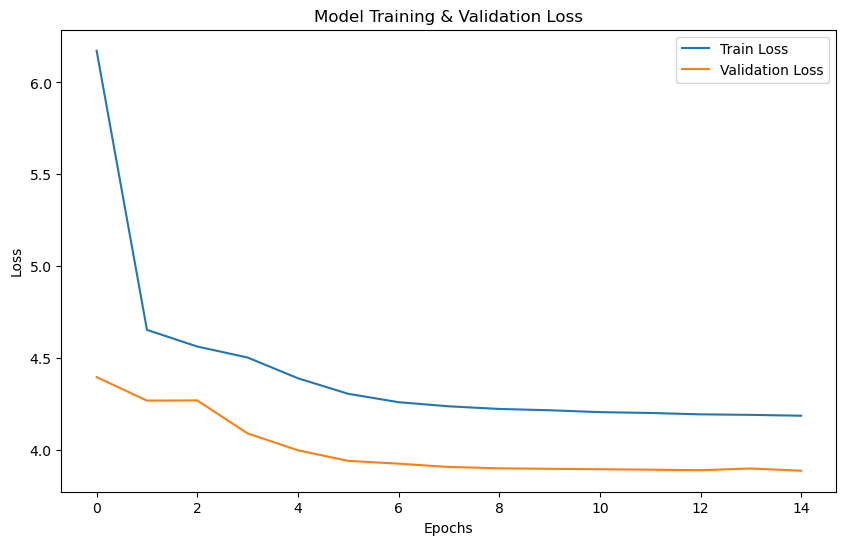

✅ Loss 그래프 출력 완료! (Loss가 감소하는 것을 확인하여 성공적 학습 증명)


In [10]:
# 1. Seq2Seq 모델 설계
embedding_dim = 128
hidden_size = 256

# 인코더
encoder_inputs = Input(shape=(text_max_len,))
enc_emb = Embedding(src_vocab, embedding_dim)(encoder_inputs)
encoder_lstm = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# 디코더
decoder_inputs = Input(shape=(None,))
dec_emb_layer = Embedding(tar_vocab, embedding_dim)
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# 출력층
decoder_softmax_layer = Dense(tar_vocab, activation='softmax')
decoder_softmax_outputs = decoder_softmax_layer(decoder_outputs)

# 모델 정의 및 컴파일
model = Model([encoder_inputs, decoder_inputs], decoder_softmax_outputs)
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')

# 2. 모델 학습 (EarlyStopping으로 과적합 방지)
es = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

print("🚀 모델 학습을 시작합니다. (몇 분 정도 소요될 수 있습니다)")
history = model.fit(x=[encoder_input_train, decoder_input_train[:,:-1]], 
                    y=decoder_input_train[:, 1:], 
                    validation_data=([encoder_input_test, decoder_input_test[:,:-1]], decoder_input_test[:, 1:]),
                    batch_size=256, callbacks=[es], epochs=15)

# 3. Train loss와 Validation loss 감소 경향 시각화
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
print("✅ Loss 그래프 출력 완료! (Loss가 감소하는 것을 확인하여 성공적 학습 증명)")

In [12]:
# 1. 인퍼런스(추론) 모델 설계
# [수정됨] outputs에서 불필요한 encoder_outputs를 제거하고 상태값(state_h, state_c)만 디코더로 넘기도록 수정했습니다.
encoder_model = Model(inputs=encoder_inputs, outputs=[state_h, state_c])

decoder_state_input_h = Input(shape=(hidden_size,))
decoder_state_input_c = Input(shape=(hidden_size,))

dec_emb2 = dec_emb_layer(decoder_inputs)
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])
decoder_outputs2 = decoder_softmax_layer(decoder_outputs2)

decoder_model = Model(
    [decoder_inputs] + [decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2])

# 역변환 사전
src_index_to_word = src_tokenizer.index_word
tar_word_to_index = tar_tokenizer.word_index
tar_index_to_word = tar_tokenizer.index_word

# 2. 문장 생성 함수
def decode_sequence(input_seq):
    states_value = encoder_model.predict(input_seq, verbose=0)
    target_seq = np.zeros((1,1))
    target_seq[0, 0] = tar_word_to_index['sostoken']
    
    stop_condition = False
    decoded_sentence = ""
    
    while not stop_condition:
        # states_value는 이제 [state_h, state_c] 2개의 요소만 가지므로 정상적으로 3개의 input이 맞춰집니다.
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = tar_index_to_word.get(sampled_token_index, '')
        
        if sampled_word != 'eostoken' and sampled_word != '':
            decoded_sentence += ' ' + sampled_word
            
        if sampled_word == 'eostoken' or len(decoded_sentence.split()) >= (summary_max_len-1):
            stop_condition = True
            
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]
        
    return decoded_sentence.strip()

# 시퀀스 변환 함수
def seq2text(input_seq):
    return ' '.join([src_index_to_word.get(i, '') for i in input_seq if i != 0])
def seq2summary(input_seq):
    return ' '.join([tar_index_to_word.get(i, '') for i in input_seq if i not in [0, tar_word_to_index.get('sostoken', 0), tar_word_to_index.get('eostoken', 0)]])

# 3. 결과 비교 (5개 샘플)
results = []
for i in range(5):
    original_text = seq2text(encoder_input_test[i])
    actual_summary = seq2summary(decoder_input_test[i])
    abs_summary = decode_sequence(encoder_input_test[i].reshape(1, text_max_len))
    
    # Extractive 요약 (summa)
    ext_summary = summarize(original_text, ratio=0.5)
    # Extractive 결과가 짧아서 빈 문자열이 나올 경우 방어 코드
    if not ext_summary:
        ext_summary = summarize(original_text, words=15)
        if not ext_summary: # 그래도 없으면 원문의 일부 반환
            ext_summary = ' '.join(original_text.split()[:10]) + "..."
            
    results.append({
        'Original Text (전처리됨)': original_text[:100] + "...", 
        'Actual Summary': actual_summary, 
        'Abstractive (딥러닝)': abs_summary, 
        'Extractive (Summa)': ext_summary
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)
print("✅ 두 요약 결과 비교표 출력 완료!")

,Original Text (전처리됨),Actual Summary,Abstractive (딥러닝),Extractive (Summa)
0,news australia criticised calling indian crick...,australian calls indian players,india to in in,news australia criticised calling indian crick...
1,defending champions real madrid entered th eur...,real enter league final to face,india to in in,defending champions real madrid entered th eur...
2,actress sonam kapoor turned designers abu sand...,sonam turns for,india to in in,actress sonam kapoor turned designers abu sand...
3,police arrested five people detained ten other...,in up over cow arrested,india to in in,police arrested five people detained ten other...
4,past years indian chief ministers aged years o...,indian in last years aged years,india to in in,past years indian chief ministers aged years o...


✅ 두 요약 결과 비교표 출력 완료!
